## Setup:

In [1]:
!git clone https://github.com/mat10d/EvolvePro.git
%cd EvolvePro/

Cloning into 'EvolvePro'...
remote: Enumerating objects: 1342, done.
remote: Counting objects: 100% (274/274), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 1342 (delta 222), reused 193 (delta 187), pack-reused 1068 (from 3)
Receiving objects: 100% (1342/1342), 85.11 MiB | 12.51 MiB/s, done.
Resolving deltas: 100% (706/706), done.
/content/EvolvePro


In [2]:
%%capture

!pip install pandas numpy scikit-learn scikit-learn-extra xgboost matplotlib seaborn biopython scipy torch fair-esm
!mkdir /content/output

## Process

In [3]:
from evolvepro.src.process import generate_wt, generate_single_aa_mutants
generate_wt('MAKEDNIEMQGTVLETLPNTMFRVELENGHVVTAHISGKMRKNYIRILTGDKVTVELTPYDLSKGRIVFRSR', output_file='/content/output/kelsic_WT.fasta')
generate_single_aa_mutants('/content/output/kelsic_WT.fasta', output_file='/content/output/kelsic.fasta')

Number of mutants: 1369


In [4]:
from evolvepro.src.process import suggest_initial_mutants
suggest_initial_mutants('/content/output/kelsic.fasta', num_mutants=12, random_seed=42)


Suggested 12 mutants for testing:
1. R23K
2. T58E
3. I36D
4. V31C
5. I7A
6. K3F
7. Q10P
8. G38E
9. E4M
10. D61W
11. E4Y
12. R23N


## PLM

In [5]:
!python evolvepro/plm/esm/extract.py esm1b_t33_650M_UR50S /content/output/kelsic.fasta /content/output/kelsic_esm1b_t33_650M_UR50S --toks_per_batch 512 --include mean --concatenate_dir /content/output

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm1b_t33_650M_UR50S.pt" to /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm1b_t33_650M_UR50S-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S-contact-regression.pt
Transferred model to GPU
Read /content/output/kelsic.fasta with 1369 sequences
Processing 1 of 196 batches (7 sequences)
Device: cuda:0
Processing 2 of 196 batches (7 sequences)
Device: cuda:0
Processing 3 of 196 batches (7 sequences)
Device: cuda:0
Processing 4 of 196 batches (7 sequences)
Device: cuda:0
Processing 5 of 196 batches (7 sequences)
Device: cuda:0
Processing 6 of 196 batches (7 sequences)
Device: cuda:0
Processing 7 of 196 batches (7 sequences)
Device: cuda:0
Processing 8 of 196 batches (7 sequences)
Device: cuda:0
Processing 9 of 196 batches (7 sequences)
Device: cuda:0
Processing 10 of 196 batches (7 sequences)
Device: cuda:0
Processing 1

## Run EVOLVEpro

In [6]:
from evolvepro.src.evolve import evolve_experimental

protein_name = 'kelsic'
embeddings_base_path = '/content/output'
embeddings_file_name = 'kelsic_esm1b_t33_650M_UR50S.csv'
round_base_path = '/content/EvolvePro/colab/rounds_data'
wt_fasta_path = "/content/output/kelsic_WT.fasta"
number_of_variants = 12
output_dir = '/content/output/'
rename_WT = False

#### Round 1

In [7]:
round_name = 'Round1'
round_file_names = ['kelsic_Round1.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing kelsic - Round1
Embeddings loaded: (1369, 1280)
Loaded experimental data for kelsic_Round1.xlsx: (12, 3)
iteration shape: (12, 2)
Labels shape: (1369, 5)
Embeddings and labels are aligned
(1357,)

Tested variants in this round: 12
50       E4M
347      K3F
359     G38E
498     Q10P
519      E4Y
548     I36D
557     D61W
598     T58E
622     R23N
1087    R23K
1193     I7A
1268    V31C
Name: variant, dtype: object

Top 12 variants predicted by the model:
                    variant    y_pred  y_actual  y_actual_scaled  \
969                     D5F  0.942228       NaN              NaN   
66                      D5W  0.937148       NaN              NaN   
1309                    M1N  0.936653       NaN              NaN   
264                    S71C  0.936028       NaN              NaN   
1146                    D5M  0.934065       NaN              NaN   
475                    N28C  0.932660       NaN              NaN   
1279                   T12S  0.932273       NaN         

/content/EvolvePro/evolvepro/src/model.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_train, df_test])


#### Round 2

In [8]:
round_name = 'Round2'
round_file_names = ['kelsic_Round1.xlsx', 'kelsic_Round2.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing kelsic - Round2
Embeddings loaded: (1369, 1280)
Loaded experimental data for kelsic_Round1.xlsx: (12, 3)
Loaded experimental data for kelsic_Round2.xlsx: (12, 3)
iteration shape: (24, 2)
Labels shape: (1369, 5)
Embeddings and labels are aligned
(1345,)

Tested variants in this round: 24
50       E4M
223     T12C
264     S71C
347      K3F
359     G38E
395      E8Q
498     Q10P
519      E4Y
532      E4N
538      E4Q
548     I36D
557     D61W
598     T58E
604      E4V
622     R23N
689     T12M
1014     E4F
1030     E4L
1087    R23K
1146     D5M
1193     I7A
1268    V31C
1291     E4H
1365     E8C
Name: variant, dtype: object

Top 12 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
969      D5F  1.007367       NaN              NaN              NaN   
1338     D5V  0.983815       NaN              NaN              NaN   
766      D5L  0.982225       NaN              NaN              NaN   
984      E4I  0.980975       NaN       

/content/EvolvePro/evolvepro/src/model.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_train, df_test])


#### Round 3

In [9]:
round_name = 'Round3'
round_file_names = ['kelsic_Round1.xlsx', 'kelsic_Round2.xlsx', 'kelsic_Round3.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing kelsic - Round3
Embeddings loaded: (1369, 1280)
Loaded experimental data for kelsic_Round1.xlsx: (12, 3)
Loaded experimental data for kelsic_Round2.xlsx: (12, 3)
Loaded experimental data for kelsic_Round3.xlsx: (12, 3)
iteration shape: (36, 2)
Labels shape: (1369, 5)
Embeddings and labels are aligned
(1333,)

Tested variants in this round: 36
6        D5N
50       E4M
217      M1W
223     T12C
264     S71C
347      K3F
359     G38E
395      E8Q
430      E4W
498     Q10P
519      E4Y
532      E4N
538      E4Q
548     I36D
557     D61W
598     T58E
604      E4V
622     R23N
689     T12M
755      D5Y
766      D5L
969      D5F
984      E4I
1014     E4F
1030     E4L
1077     D5C
1087    R23K
1146     D5M
1158    E25Q
1160     E4C
1189     D5I
1193     I7A
1268    V31C
1291     E4H
1338     D5V
1365     E8C
Name: variant, dtype: object

Top 12 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
506      D5Q  0.983880       NaN    

/content/EvolvePro/evolvepro/src/model.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_train, df_test])


#### Round 4

In [10]:
round_name = 'Round4'
round_file_names = ['kelsic_Round1.xlsx', 'kelsic_Round2.xlsx', 'kelsic_Round3.xlsx', 'kelsic_Round4.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing kelsic - Round4
Embeddings loaded: (1369, 1280)
Loaded experimental data for kelsic_Round1.xlsx: (12, 3)
Loaded experimental data for kelsic_Round2.xlsx: (12, 3)
Loaded experimental data for kelsic_Round3.xlsx: (12, 3)
Loaded experimental data for kelsic_Round4.xlsx: (12, 3)
iteration shape: (48, 2)
Labels shape: (1369, 5)
Embeddings and labels are aligned
(1321,)

Tested variants in this round: 48
6        D5N
42      E27C
50       E4M
217      M1W
223     T12C
264     S71C
347      K3F
359     G38E
395      E8Q
430      E4W
498     Q10P
505      D5S
506      D5Q
519      E4Y
532      E4N
538      E4Q
548     I36D
557     D61W
568     E27L
598     T58E
604      E4V
622     R23N
689     T12M
752     M21L
755      D5Y
760      D5T
766      D5L
880      D5A
916     E27Q
962     E27M
969      D5F
984      E4I
1014     E4F
1030     E4L
1060     E4T
1077     D5C
1087    R23K
1146     D5M
1158    E25Q
1160     E4C
1189     D5I
1193     I7A
1211     D5H
1216    V24I
1268    V31C
12

/content/EvolvePro/evolvepro/src/model.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_train, df_test])


#### Round 5

In [11]:
round_name = 'Round5'
round_file_names = ['kelsic_Round1.xlsx', 'kelsic_Round2.xlsx', 'kelsic_Round3.xlsx', 'kelsic_Round4.xlsx', 'kelsic_Round5.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing kelsic - Round5
Embeddings loaded: (1369, 1280)
Loaded experimental data for kelsic_Round1.xlsx: (12, 3)
Loaded experimental data for kelsic_Round2.xlsx: (12, 3)
Loaded experimental data for kelsic_Round3.xlsx: (12, 3)
Loaded experimental data for kelsic_Round4.xlsx: (12, 3)
Loaded experimental data for kelsic_Round5.xlsx: (12, 3)
iteration shape: (60, 2)
Labels shape: (1369, 5)
Embeddings and labels are aligned
(1309,)

Tested variants in this round: 60
6        D5N
42      E27C
50       E4M
66       D5W
124     S71K
156      E8F
217      M1W
223     T12C
264     S71C
297      D5P
327      E8H
347      K3F
359     G38E
395      E8Q
430      E4W
498     Q10P
505      D5S
506      D5Q
519      E4Y
532      E4N
538      E4Q
548     I36D
557     D61W
568     E27L
598     T58E
604      E4V
622     R23N
666     T20H
688     Q10H
689     T12M
723      E8K
733      E4P
750     V55I
752     M21L
755      D5Y
760      D5T
766      D5L
880      D5A
916     E27Q
962     E27M
969      D

/content/EvolvePro/evolvepro/src/model.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_train, df_test])


## Plot

In [12]:
from evolvepro.src.plot import read_exp_data, plot_variants_by_iteration

round_base_path = '/content/EvolvePro/colab/rounds_data'
round_file_names = ['kelsic_Round1.xlsx', 'kelsic_Round2.xlsx', 'kelsic_Round3.xlsx', 'kelsic_Round4.xlsx', 'kelsic_Round5.xlsx']
wt_fasta_path = "/content/output/kelsic_WT.fasta"

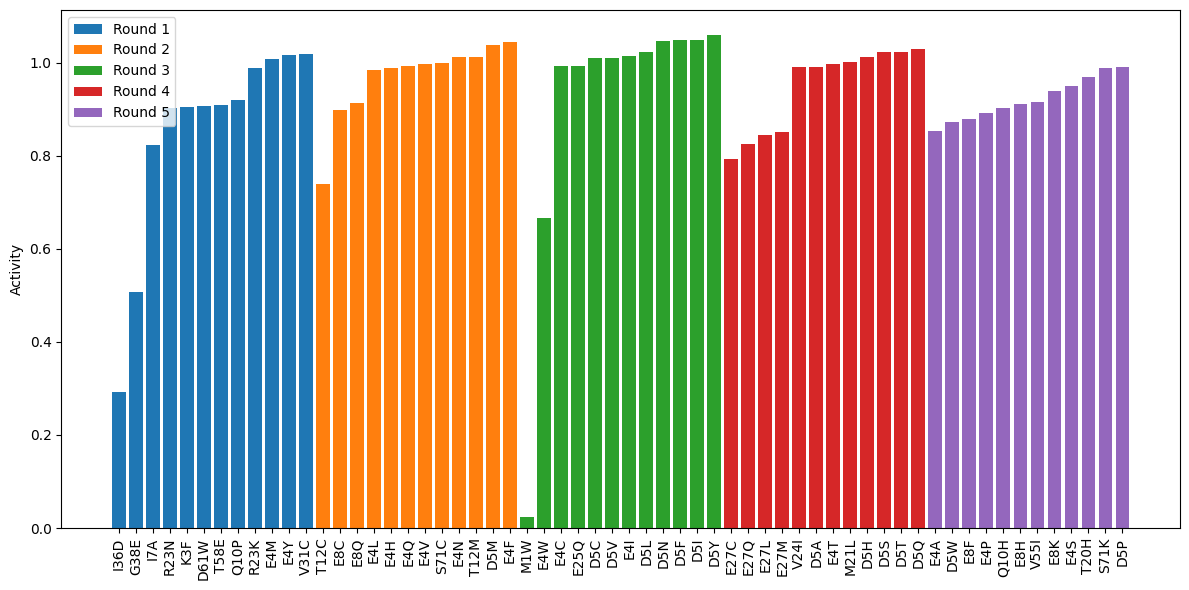

In [13]:
df = read_exp_data(round_base_path, round_file_names, wt_fasta_path)
plot_variants_by_iteration(df, activity_column='activity', output_dir=output_dir, output_file="kelsic")


# Multiple mutations

In [14]:
from evolvepro.src.process import generate_n_mutant_combinations

generate_n_mutant_combinations(
    '/content/output/kelsic_WT.fasta',
    '/content/output/mutant_activities.xlsx',
    3,
    '/content/output/kelsic_3.fasta',
)

Number of mutant combinations: 1140
Number of valid mutant combinations: 233


In [15]:
!python evolvepro/plm/esm/extract.py esm1b_t33_650M_UR50S /content/output/kelsic_3.fasta /content/output/kelsic_3_esm1b_t33_650M_UR50S --toks_per_batch 512 --include mean --concatenate_dir /content/output

Transferred model to GPU
Read /content/output/kelsic_3.fasta with 233 sequences
Processing 1 of 34 batches (7 sequences)
Device: cuda:0
Processing 2 of 34 batches (7 sequences)
Device: cuda:0
Processing 3 of 34 batches (7 sequences)
Device: cuda:0
Processing 4 of 34 batches (7 sequences)
Device: cuda:0
Processing 5 of 34 batches (7 sequences)
Device: cuda:0
Processing 6 of 34 batches (7 sequences)
Device: cuda:0
Processing 7 of 34 batches (7 sequences)
Device: cuda:0
Processing 8 of 34 batches (7 sequences)
Device: cuda:0
Processing 9 of 34 batches (7 sequences)
Device: cuda:0
Processing 10 of 34 batches (7 sequences)
Device: cuda:0
Processing 11 of 34 batches (7 sequences)
Device: cuda:0
Processing 12 of 34 batches (7 sequences)
Device: cuda:0
Processing 13 of 34 batches (7 sequences)
Device: cuda:0
Processing 14 of 34 batches (7 sequences)
Device: cuda:0
Processing 15 of 34 batches (7 sequences)
Device: cuda:0
Processing 16 of 34 batches (7 sequences)
Device: cuda:0
Processing 17 of 

In [22]:
from evolvepro.src.evolve import evolve_experimental_multi

round_name = 'Round6'
round_file_names_single = ['kelsic_Round1.xlsx', 'kelsic_Round2.xlsx', 'kelsic_Round3.xlsx', 'kelsic_Round4.xlsx', 'kelsic_Round5.xlsx']
round_file_names_multi = []
embeddings_file_name_3 = 'kelsic_3_esm1b_t33_650M_UR50S.csv'


evolve_experimental_multi(
    protein_name,
    round_name,
    embeddings_base_path,
    [embeddings_file_name, embeddings_file_name_3],
    round_base_path,
    round_file_names_single,
    round_file_names_multi,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing kelsic - Round6
Embeddings loaded: (1601, 1280)
Loaded experimental data for kelsic_Round1.xlsx: (12, 3)
Loaded experimental data for kelsic_Round2.xlsx: (12, 3)
Loaded experimental data for kelsic_Round3.xlsx: (12, 3)
Loaded experimental data for kelsic_Round4.xlsx: (12, 3)
Loaded experimental data for kelsic_Round5.xlsx: (12, 3)
Embeddings and labels are aligned
(1541,)

Tested variants in this round: 60
6        D5N
42      E27C
50       E4M
66       D5W
124     S71K
156      E8F
217      M1W
223     T12C
264     S71C
297      D5P
327      E8H
347      K3F
359     G38E
395      E8Q
430      E4W
498     Q10P
505      D5S
506      D5Q
519      E4Y
532      E4N
538      E4Q
548     I36D
557     D61W
568     E27L
598     T58E
604      E4V
622     R23N
666     T20H
688     Q10H
689     T12M
723      E8K
733      E4P
750     V55I
752     M21L
755      D5Y
760      D5T
766      D5L
880      D5A
916     E27Q
962     E27M
969      D5F
984      E4I
1014     E4F
1018     E4A
1030   

/content/EvolvePro/evolvepro/src/model.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_train, df_test])


(6        D5N
 42      E27C
 50       E4M
 66       D5W
 124     S71K
 156      E8F
 217      M1W
 223     T12C
 264     S71C
 297      D5P
 327      E8H
 347      K3F
 359     G38E
 395      E8Q
 430      E4W
 498     Q10P
 505      D5S
 506      D5Q
 519      E4Y
 532      E4N
 538      E4Q
 548     I36D
 557     D61W
 568     E27L
 598     T58E
 604      E4V
 622     R23N
 666     T20H
 688     Q10H
 689     T12M
 723      E8K
 733      E4P
 750     V55I
 752     M21L
 755      D5Y
 760      D5T
 766      D5L
 880      D5A
 916     E27Q
 962     E27M
 969      D5F
 984      E4I
 1014     E4F
 1018     E4A
 1030     E4L
 1060     E4T
 1077     D5C
 1087    R23K
 1146     D5M
 1158    E25Q
 1160     E4C
 1189     D5I
 1193     I7A
 1211     D5H
 1216    V24I
 1220     E4S
 1268    V31C
 1291     E4H
 1338     D5V
 1365     E8C
 Name: variant, dtype: object,
            variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
 1472  E4N_D5Q_M21L  1.004693       NaN             

In [19]:
embeddings_base_path

'Round5'